# LSA (Latent Semantic Analysis) Recommender
After building the TF-IDF baseline, I extended the recommender with **Latent Semantic Analysis (LSA)** using **Truncated SVD**. The idea is to start from the same TF-IDF matrix, but then reduce that sparse high-dimensional representation into a smaller latent space.

Now the definition of similarity changes. In the TF-IDF baseline, songs are similar when they share many of the same distinctive words or phrases. In the LSA model, songs are similar when they occupy nearby positions in a lower dimensional semantic space shaped by broader word co-occurrence patterns across the corpus.

We can then capture songs expressing similar themes without using the exact same vocabulary. By compressing the TF-IDF matrix into latent dimensions, LSA can capture relationships that are not always visible through direct lexical overlap alone.

**Pipeline:**
1. Build TF-IDF matrix 
2. Apply TruncatedSVD to reduce to `n_components` latent dimensions
3. Normalize and compute cosine similarity on the reduced matrix
4. Compare recommendations against TF-IDF baseline across the same seed songs


## 1. Imports & Setup

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer

from lsa_recommender import (
    build_lsa_recommender,
    recommend_songs,
    get_top_topics,
    get_song_top_topics
)
# Import TF-IDF recommender for direct side-by-side comparison
from tfidf_recommender import (
    build_tfidf_recommender,
    recommend_songs as tfidf_recommend
)

pd.set_option('display.max_colwidth', 60)
print('Imports successful.')

Imports successful.


## 2. Recommenders

In [2]:
LYRICS_PATH = '../data/processed/lyrics_clean.csv'
N_COMPONENTS = 100  # number of latent topics - to be experimented with below

# LSA
lyrics_df, lsa_matrix, lsa_sim, svd, vectorizer = build_lsa_recommender(
    LYRICS_PATH, n_components=N_COMPONENTS
)

# TF-IDF baseline
_, tfidf_matrix, tfidf_sim = build_tfidf_recommender(LYRICS_PATH)

print(f'Songs:              {len(lyrics_df)}')
print(f'TF-IDF matrix:      {tfidf_matrix.shape}  (songs x vocab terms)')
print(f'LSA matrix:         {lsa_matrix.shape}   (songs x latent topics)')
print(f'Explained variance: {svd.explained_variance_ratio_.sum():.1%} of total variance captured in {N_COMPONENTS} components')

Songs:              1688
TF-IDF matrix:      (1688, 10000)  (songs x vocab terms)
LSA matrix:         (1688, 100)   (songs x latent topics)
Explained variance: 21.7% of total variance captured in 100 components


The original TF-IDF matrix has shape **(1688, 10000)**, meaning that 1,688 songs are represented across 10,000 vocabulary features. After applying Truncated SVD with **100 components**, the representation is reduced to an **LSA matrix of shape (1688, 100)**.

This reduced representation captures approximately **21.7% of the total variance** in the original TF-IDF space. While that means some information is compressed away, the tradeoff is that the model can focus on broader latent structure instead of isolated  overlap between words alone. The LSA recommender is designed to sacrifice some surface detail in exchange for a more general semantic representation of lyrical similarity.

## 3. Inspecting the Latent Topics
Each component is defined by terms that tend to co-occur across songs, allowing the model to group together songs that may share themes, moods, or narrative structure even when their exact wording differs. Inspecting the highest weighted terms in each component helps show what kinds of lyrical patterns the recommender is learning from the corpus.

In [3]:
topics_df = get_top_topics(svd, vectorizer, n_topics=20, n_terms=8)
print("Top 8 terms per latent topic:\n")
topics_df

Top 8 terms per latent topic:



,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10,Topic 11,Topic 12,Topic 13,Topic 14,Topic 15,Topic 16,Topic 17,Topic 18,Topic 19,Topic 20
0,im,la,ooh,yeah,oh,dont,love,oh,im,hey,que,hey,know,want,feel,da,ive,da,ill,ill
1,dont,la la,ooh ooh,yeah yeah,yeah,know,baby,oh oh,baby,hey hey,im,wanna,know know,want want,like,want,time,doo,world,shes
2,know,que,yeah,nigga,oh oh,wanna,dont,baby,hey,que,el,hey hey,love,im,feel like,doo,got,come,wanna,tonight
3,like,ooh,oh,like,yeah yeah,dont know,want,im,hey hey,know,te,dont wanna,hey,love,just,gonna,want,feel,want,wait
4,just,el,yeah yeah,bitch,baby,dont wanna,love love,nigga,la la,baby,love,dont,shes,youre,wanna,da da,ive got,da da,away,just
5,love,doo,oh oh,got,wanna,know know,hey,bitch,gonna,want,en,im,hey hey,dont want,shes,wanna,feel,like,know know,youre
6,oh,en,love,im,dont,im,baby baby,got,im gonna,know know,lo,ill,dont know,oh,baby,doo doo,wanna,away,dont wanna,girl
7,yeah,ooh ooh,ah,fuck,know,want,wanna,like,yeah,el,mi,oh oh,like,ha,dream,youre,want want,doo doo,know,let


## Scree Plot for Choosing n-components 
How much variance does each additional component add? The "elbow" in this plot is a natural stopping point.

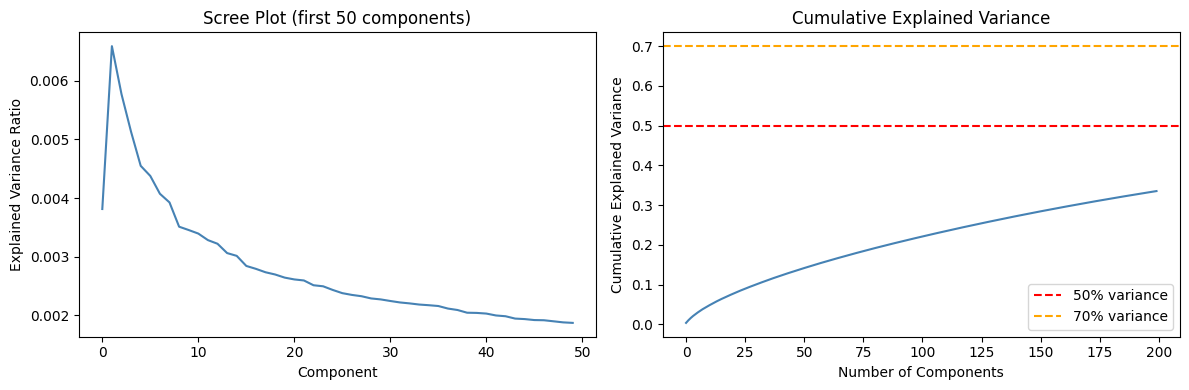

30% variance captured at 165 components
50% variance captured at 1 components
70% variance captured at 1 components


In [4]:
vec_inspect = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2)
tfidf_inspect = vec_inspect.fit_transform(lyrics_df['processed_lyrics'])

svd_inspect = TruncatedSVD(n_components=200, random_state=42)
svd_inspect.fit(tfidf_inspect)

cumvar = svd_inspect.explained_variance_ratio_.cumsum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(svd_inspect.explained_variance_ratio_[:50], color='steelblue')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot (first 50 components)')

axes[1].plot(cumvar, color='steelblue')
axes[1].axhline(0.5, color='red', linestyle='--', label='50% variance')
axes[1].axhline(0.7, color='orange', linestyle='--', label='70% variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()

plt.tight_layout()
plt.show()

for threshold in [0.3, 0.5, 0.7]:
    n = (cumvar >= threshold).argmax() + 1
    print(f'{threshold:.0%} variance captured at {n} components')


## Side-by-Side Recommendations

In [5]:
def compare_models(seed_title, seed_artist=None, k=10):
    """Print TF-IDF and LSA recommendations side by side for a seed song."""
    tfidf_recs = tfidf_recommend(
        lyrics_df, tfidf_sim, seed_title=seed_title, seed_artist=seed_artist, k=k
    ).rename(columns={"similarity": "tfidf_score"})

    lsa_recs = recommend_songs(
        lyrics_df, lsa_sim, seed_title=seed_title, seed_artist=seed_artist, k=k
    ).rename(columns={"similarity": "lsa_score"})

    tfidf_recs.index += 1
    lsa_recs.index += 1

    print(f"\nSeed: '{seed_title}'{' by ' + seed_artist if seed_artist else ''}")
    print(f"{'Rank':<5} {'── TF-IDF ──':<45} {'── LSA ──':<45}")
    print('-' * 95)
    for i in range(1, k + 1):
        t = tfidf_recs.loc[i]
        l = lsa_recs.loc[i]
        t_str = f"{t['track_name'][:28]} — {t['artist'][:14]} ({t['tfidf_score']:.3f})"
        l_str = f"{l['track_name'][:28]} — {l['artist'][:14]} ({l['lsa_score']:.3f})"
        print(f"{i:<5} {t_str:<45} {l_str:<45}")

    return tfidf_recs, lsa_recs

In [6]:
# --- Grunge ---
tfidf_grunge, lsa_grunge = compare_models('Iron Clad Lou', seed_artist='Hum')


Seed: 'Iron Clad Lou' by Hum
Rank  ── TF-IDF ──                                  ── LSA ──                                    
-----------------------------------------------------------------------------------------------
1     Stand up and Win — Spymob (0.151)             Never Lonely — Space Mountain (0.523)        
2     Never Lonely — Space Mountain (0.142)         Lonely Mess — Laundry (0.496)                
3     Downtown — Varsity (0.127)                    Stadium Arcadium — Red Hot Chili  (0.494)    
4     Rain — World's Experi (0.123)                 Hell N Back — Bakar (0.487)                  
5     Faxing It In — Smushie (0.115)                Wake up Jacob — Sitcom (0.460)               
6     Hippies — flipturn (0.113)                    Place To Be — Nick Drake (0.459)             
7     Alive — Pearl Jam (0.109)                     muscles — not dvr (0.456)                    
8     2023 — Blue Rain Boot (0.109)                 November — Psychedelic Po (0.449)     

In [7]:
# --- Soul ---
tfidf_soul, lsa_soul = compare_models("Can I Help You?", seed_artist='Amnesty')


Seed: 'Can I Help You?' by Amnesty
Rank  ── TF-IDF ──                                  ── LSA ──                                    
-----------------------------------------------------------------------------------------------
1     Sweetest Thing on This Side  — Papa Bear & Hi (0.302) Sweetest Thing on This Side  — Papa Bear & Hi (0.545)
2     Chicago — Michael Jackso (0.166)              Simulation — Reptaliens (0.496)              
3     Bailee — The Licks (0.160)                    Some Are Lakes — Land of Talk (0.477)        
4     Wizard Of Finance — Parliament (0.143)        Let's Get Lost — Chet Baker (0.452)          
5     Cause = Time — Broken Social  (0.141)         Grow Forever — Lizette & Quev (0.429)        
6     Mystery Girl — Housecall (0.118)              In The Heat Of The Morning — The Last Shado (0.427)
7     Ellie — Make Friends (0.117)                  Someone To Spend Time With — Los Retros (0.426)
8     Hard To Handle — The Black Crow (0.095)       Palm Tre

In [8]:
# --- Latin ---
tfidf_latin, lsa_latin = compare_models(
    'Los Libros de la Buena Memoria', seed_artist='Invisible'
)


Seed: 'Los Libros de la Buena Memoria' by Invisible
Rank  ── TF-IDF ──                                  ── LSA ──                                    
-----------------------------------------------------------------------------------------------
1     My Conception — Ryo Fukui (0.655)             My Conception — Ryo Fukui (0.992)            
2     SMUCKERS (feat. Lil Wayne &  — Tyler, The Cre (0.494) La Balsa — Los Gatos (0.985)                 
3     Las Habladurias del Mundo — Pescado Rabios (0.462) Elementales Leches — Invisible (0.975)       
4     After The Storm (feat. Tyler — Kali Uchis (0.442) Como Mata el Viento Norte — La Maquina De  (0.975)
5     Como Mata el Viento Norte — La Maquina De  (0.418) SMUCKERS (feat. Lil Wayne &  — Tyler, The Cre (0.974)
6     Oh Qué Será? — Willie Colón (0.411)           Oh Qué Será? — Willie Colón (0.973)          
7     Promesas Sobre El Bidet — Charly García (0.362) Danger (Spider) (Offset & JI — Offset (0.970)
8     ･－･･ ･ － ･･ － －－･ －－－ — 

In [9]:
# --- Hip-hop ---
tfidf_hiphop, lsa_hiphop = compare_models('House Money', seed_artist='Baby Keem')


Seed: 'House Money' by Baby Keem
Rank  ── TF-IDF ──                                  ── LSA ──                                    
-----------------------------------------------------------------------------------------------
1     Jesus Is The One (I Got Depr — Zack Fox (0.445) Jesus Is The One (I Got Depr — Zack Fox (0.897)
2     Can You Rap Like Me? — Trippie Redd (0.367)   Can You Rap Like Me? — Trippie Redd (0.834)  
3     Hit Bout It — Lil Yachty (0.332)              trademark usa — Baby Keem (0.826)            
4     Blood On Me — Sampha (0.323)                  REEL IT IN — Aminé (0.825)                   
5     REEL IT IN — Aminé (0.290)                    Hit Bout It — Lil Yachty (0.812)             
6     trademark usa — Baby Keem (0.275)             JayJay-Z — Zelooperz (0.798)                 
7     JayJay-Z — Zelooperz (0.270)                  CORSO — Tyler, The Cre (0.775)               
8     Fresh Prince Of Utah — YoungBoy Never (0.269) Fresh Prince Of Utah — YoungBo

## Overlap Analysis

In [10]:
def overlap_stats(tfidf_recs, lsa_recs, label):
    tfidf_set = set(zip(tfidf_recs['track_name'], tfidf_recs['artist']))
    lsa_set   = set(zip(lsa_recs['track_name'],   lsa_recs['artist']))
    shared    = tfidf_set & lsa_set
    jaccard   = len(shared) / len(tfidf_set | lsa_set)
    print(f"{label}")
    print(f"  Shared songs:    {len(shared)}/10")
    print(f"  Jaccard score:   {jaccard:.2f}")
    if shared:
        print(f"  Overlap:         {', '.join([s[0] for s in shared])}")
    print()

overlap_stats(tfidf_grunge,  lsa_grunge,  'Grunge  (Iron Clad Lou)')
overlap_stats(tfidf_soul,    lsa_soul,    'Soul    (Can I Help You?)')
overlap_stats(tfidf_latin,   lsa_latin,   'Latin   (Los Libros...)')
overlap_stats(tfidf_hiphop,  lsa_hiphop,  'Hip-hop (House Money)')

Grunge  (Iron Clad Lou)
  Shared songs:    3/10
  Jaccard score:   0.18
  Overlap:         Down the Line, Never Lonely, Faxing It In

Soul    (Can I Help You?)
  Shared songs:    2/10
  Jaccard score:   0.11
  Overlap:         Cause = Time, Sweetest Thing on This Side of Heaven

Latin   (Los Libros...)
  Shared songs:    7/10
  Jaccard score:   0.54
  Overlap:         La Balsa, My Conception, Las Habladurias del Mundo, Como Mata el Viento Norte, Oh Qué Será?, SMUCKERS (feat. Lil Wayne & Kanye West), Elementales Leches

Hip-hop (House Money)
  Shared songs:    8/10
  Jaccard score:   0.67
  Overlap:         CORSO, Can You Rap Like Me?, Jesus Is The One (I Got Depression), REEL IT IN, trademark usa, JayJay-Z, Hit Bout It, Fresh Prince Of Utah



## N-components Test

In [11]:
results_by_k = {}
for n in [50, 100, 200]:
    _, _, sim_n, _, _ = build_lsa_recommender(LYRICS_PATH, n_components=n)
    recs = recommend_songs(lyrics_df, sim_n, 'House Money', 'Baby Keem', k=10)
    results_by_k[n] = set(zip(recs['track_name'], recs['artist']))
    print(f"n={n}: {list(recs['track_name'])[:5]}")

print(f"\nOverlap 50 vs 100:  {len(results_by_k[50]  & results_by_k[100])}/10")
print(f"Overlap 100 vs 200: {len(results_by_k[100] & results_by_k[200])}/10")
print(f"Overlap 50 vs 200:  {len(results_by_k[50]  & results_by_k[200])}/10")

n=50: ['Hit Bout It', 'Jesus Is The One (I Got Depression)', 'CORSO', 'trademark usa', 'JayJay-Z']
n=100: ['Jesus Is The One (I Got Depression)', 'Can You Rap Like Me?', 'trademark usa', 'REEL IT IN', 'Hit Bout It']
n=200: ['Jesus Is The One (I Got Depression)', 'Can You Rap Like Me?', 'REEL IT IN', 'trademark usa', 'Hit Bout It']

Overlap 50 vs 100:  8/10
Overlap 100 vs 200: 8/10
Overlap 50 vs 200:  7/10


## Similarity Score Distribution: LSA vs TF-IDF

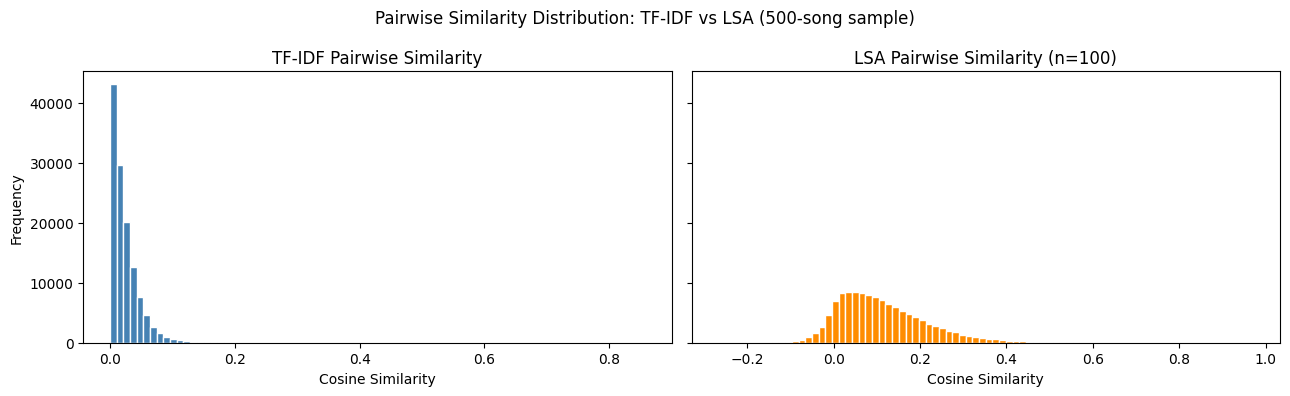

TF-IDF:  mean=0.0237  median=0.0172  >0.1: 1.4%  >0.3: 0.1%
LSA:  mean=0.1134  median=0.0946  >0.1: 47.9%  >0.3: 5.6%


In [12]:
sample_size = 500
rng = np.random.default_rng(42)
idx = rng.choice(len(lyrics_df), size=sample_size, replace=False)

lsa_sample   = lsa_sim[np.ix_(idx, idx)]
tfidf_sample = tfidf_sim[np.ix_(idx, idx)]

lsa_upper   = lsa_sample[np.triu_indices(sample_size, k=1)]
tfidf_upper = tfidf_sample[np.triu_indices(sample_size, k=1)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

axes[0].hist(tfidf_upper, bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('TF-IDF Pairwise Similarity')
axes[0].set_xlabel('Cosine Similarity')
axes[0].set_ylabel('Frequency')

axes[1].hist(lsa_upper, bins=80, color='darkorange', edgecolor='white')
axes[1].set_title(f'LSA Pairwise Similarity (n={N_COMPONENTS})')
axes[1].set_xlabel('Cosine Similarity')

plt.suptitle('Pairwise Similarity Distribution: TF-IDF vs LSA (500-song sample)')
plt.tight_layout()
plt.show()

for label, arr in [('TF-IDF', tfidf_upper), ('LSA', lsa_upper)]:
    print(f"{label}:  mean={arr.mean():.4f}  median={np.median(arr):.4f}  "
          f">0.1: {(arr > 0.1).mean()*100:.1f}%  >0.3: {(arr > 0.3).mean()*100:.1f}%")

LSA scores are higher on average more normally distributed. TF-IDF scores cluster near zero because exact vocabulary overlap is rare. This distribution shift is one reason LSA sometimes produces better recommendatons - it can find connections TF-IDF misses - but also why it can over connected unrelated songs. 

## Dominant Topics Per Seed Song

In [13]:
seeds = [
    ('Iron Clad Lou',                 'Hum'),
    ("Can I Help You?",               'Amnesty'),
    ('Los Libros de la Buena Memoria','Invisible'),
    ('House Money',                   'Baby Keem'),
]

for title, artist in seeds:
    try:
        topic_scores = get_song_top_topics(
            lyrics_df, lsa_matrix, title, seed_artist=artist, n_topics=5
        )
        print(f"'{title}' — dominant topics:")
        print(topic_scores.to_string())
        print()
    except ValueError as e:
        print(f"[NOT FOUND] {e}\n")

'Iron Clad Lou' — dominant topics:
Topic 1     0.4008
Topic 97   -0.2340
Topic 36   -0.2037
Topic 85    0.2023
Topic 78   -0.1923

'Can I Help You?' — dominant topics:
Topic 1     0.2837
Topic 44   -0.2340
Topic 48    0.2332
Topic 82    0.2230
Topic 63   -0.2228

'Los Libros de la Buena Memoria' — dominant topics:
Topic 11    0.6639
Topic 2     0.5176
Topic 10    0.2895
Topic 9    -0.2751
Topic 13   -0.1661

'House Money' — dominant topics:
Topic 4    0.4768
Topic 1    0.3829
Topic 8    0.2581
Topic 5   -0.2067
Topic 7    0.1822



## 10. Observations & Comparison Notes


**Where LSA improved over TF-IDF:**
- ...

**Where LSA performed similarly or worse:**
- ...

**Overlap findings (from Section 6):**
- High overlap genres (models agree): ...
- Low overlap genres (models disagree): ...

**What the topic inspection revealed:**
- ...

**Effect of n_components:**
- ...

**Connection to paper argument:**  
TF-IDF and LSA represent two different theories of lyrical similarity — exact vocabulary matching vs. latent thematic overlap. Where they agree, the signal is strong. Where they diverge, it reveals whether genre similarity is driven by specific shared words or broader shared themes. Neither captures acoustic or behavioral signals, which is the structural limitation both models share.

**Up next — Phase 3:** Chorus-only TF-IDF. Does restricting input to hooks (the most thematically concentrated part of a song) produce more genre-coherent recommendations than full lyrics?